# COVID-19 Classification using Machine Learning Models

This notebook implements classification models including Logistic Regression, SVM, and Decision Tree for COVID-19 detection using chest X-ray images.

In [ ]:
import os
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression #, LinearRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [28]:
# Load and preprocess data
def load_data(folder):
    data = []
    labels = []
    for label, class_name in enumerate(['Covid', 'Normal', 'Viral Pneumonia']):
        path = os.path.join(folder, class_name)
        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (64, 64))
                data.append(img.flatten())
                labels.append(label)
    return np.array(data), np.array(labels)

X_train, y_train = load_data('Covid19-dataset/train')
X_test, y_test = load_data('Covid19-dataset/test')

# Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0


Logistic Regression
Logistic Regression Accuracy: 0.8788
                 precision    recall  f1-score   support

          Covid       0.93      0.96      0.94        26
         Normal       0.89      0.80      0.84        20
Viral Pneumonia       0.81      0.85      0.83        20

       accuracy                           0.88        66
      macro avg       0.87      0.87      0.87        66
   weighted avg       0.88      0.88      0.88        66



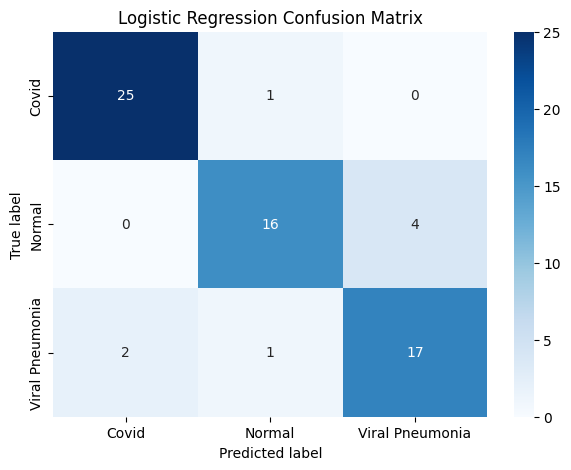


SVM
SVM Accuracy: 0.8636
                 precision    recall  f1-score   support

          Covid       0.92      0.92      0.92        26
         Normal       0.89      0.80      0.84        20
Viral Pneumonia       0.77      0.85      0.81        20

       accuracy                           0.86        66
      macro avg       0.86      0.86      0.86        66
   weighted avg       0.87      0.86      0.86        66



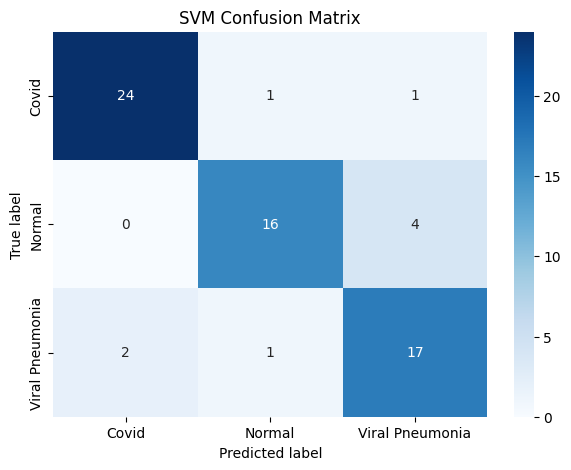


Decision Tree
Decision Tree Accuracy: 0.7121
                 precision    recall  f1-score   support

          Covid       0.96      0.85      0.90        26
         Normal       0.71      0.50      0.59        20
Viral Pneumonia       0.52      0.75      0.61        20

       accuracy                           0.71        66
      macro avg       0.73      0.70      0.70        66
   weighted avg       0.75      0.71      0.72        66



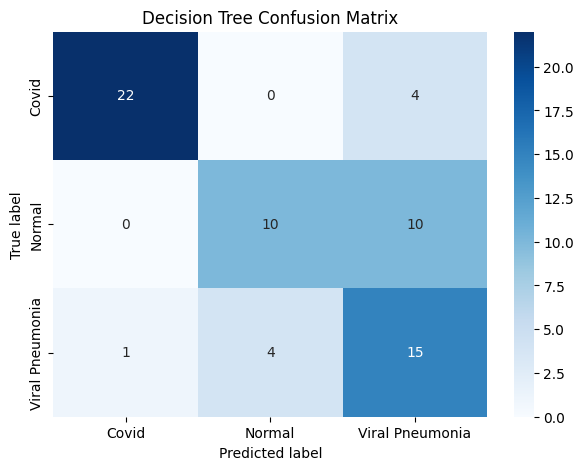

In [ ]:
class_names = ['Covid', 'Normal', 'Viral Pneumonia']

# Train models
models = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000),
        'params': {'C': [0.1, 1, 10]}
    },
    'SVM': {
        'model': SVC(probability=True),
        'params': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(),
        'params': {'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]}
    },
    # 'Linear Regression': {
    #     'model': LinearRegression(),
    #     'params': {}
    # }
}

best_models = {}

for name, config in models.items():
    print(f'\n{name}')

    if config['params']:
        grid = GridSearchCV(
            config['model'],
            config['params'],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
    else:
        best_model = config['model']
        best_model.fit(X_train, y_train)

    best_models[name] = best_model

    y_pred = best_model.predict(X_test)

    print(f'{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print(classification_report(y_test, y_pred, target_names=class_names))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

In [30]:
# Export all models
for name, model in best_models.items():
    joblib.dump(model, f'{name.replace(" ", "_").lower()}_model.pkl')
    print(f'Saved {name} model as {name.replace(" ", "_").lower()}_model.pkl')

Saved Logistic Regression model as logistic_regression_model.pkl
Saved SVM model as svm_model.pkl
Saved Decision Tree model as decision_tree_model.pkl
